# Odds and Addends

## Odds

One way to represent a probability is with a number between 1 and 0. As an alternative, you can give an odds ration, like '3 to 1' which expresses the odds in favor of an event as the ratio of the probability it will occur to the ratio probability it will not. 

In [81]:
def odds(p):
    return p / (1-p)

In [82]:
odds(0.75)

3.0

When the odds are small, it is common to report the odds against. For instance if the odds are 1:9:

In [83]:
# instead of this
print(odds(0.1))

# you can have this
print(odds(0.9))

0.11111111111111112
9.000000000000002


In [84]:
def prob(o):
    return o / (o+1)

In [85]:
prob(3/2)

0.6

If you represent odds with an numerator and a denominator, you can convert probablility like this:

In [86]:
def prob2(yes, no):
    return yes / (yes + no)

prob2(3,2)

0.6

## Bayes's Rule

So far we have worked with Bayes's theorem in the "probability form":

$$ P(H|D) = \frac{P(H)\,P(D|H)}{P(D)} $$

By writing odds(A) for odds in favor of A, we can express the Bayes's theorem in "odds form":

$$ odds(A|D) = odds(A) \frac{P(D|A)}{P(D|B)} $$

Let's apply it to the cookie problem:

In [87]:
prior_odds = 1 # as in 1:1 or 50% for bowl 1 or bowl 2
likelihood_ratio = (3/4) / (1/2) # relating to the vanilla to chocolate ratios for the bowls
post_odds = prior_odds * likelihood_ratio
post_odds

1.5

In [88]:
post_prob = prob(post_odds)
post_prob

0.6

If we draw another cookie and it's chocolate, we can do another update:

In [89]:
likelihood_ratio = (1/4) / (1/2)
post_odds *= likelihood_ratio
post_odds

0.75

In [90]:
# and we can convert it back
post_prob = prob(post_odds)
post_prob

0.42857142857142855

## Oliver's Blood

Another hypothetical:

- Two people leave traces of blood at a crime scene.
- A suspect, Oliver, is found to have blood type 'O'.
- The two traces are found to be 'O' (60% of the population) and 'AB' (about 1% of the population)

Does this evidence support the case for Oliver's involvement or work against it?

Let's use Bayes's rule:

$$ odds(A|D) = odds(A) \frac{P(D|A)}{P(D|B)} $$

By dividing through with odds(A) we get:

$$ \frac {odds(A|D)}{odds(A)} = \frac{P(D|A)}{P(D|B} $$

The term on the left is the ration of the posterior and prior odds. The term on the right is the likelihood ratio, also called the Bayes factor. 

If the Bayes factor is greater than 1, it means the odds are better under A than under B. If it is less than 1, the odds are greater under B. If it equals 1, the odds are equal under either hypothesis. 

Equation setup:

- A = hypothesis that Oliver was one of the two people at the crime scene
- B = the alternative the Oliver was not one of the people at the crime scene
- D = the data, the observation of two blood samples at the crime scene

So:

$$ odds(A|D) = odds(A) \frac{P(D|A)} {P(D|B)} $$

And then:

$$ \frac{odds(A|D)}{odds(A)} = \frac{P(D|A)} {P(D|B)} $$

In [91]:
# let's calculate
like1 = 0.01
like2 = 2 * .6 * .01

likelihood_ratio = like1 / like2
likelihood_ratio

0.8333333333333334

In [92]:
post_odds = 1 * like1 / like2
prob(post_odds)

0.45454545454545453

Since the likelihood ratio is less than 1, the blood tests are evidence against Oliver's involvement. This pushes the odds down. 

In [93]:
# Exercise 6-1

# If we believe with 90% assurity that he was involved given other evidence, how much would the blood change the assessment?
prior_odds = 9/1
print(prior_odds) # as the alternative prior '1' in the first scenario
post_odds = prior_odds * like1 / like2
prob(post_odds)

9.0


0.8823529411764706

The blood work brings the odds down slightly but not enough to overwhelm the prior evidence. 

## Addends

Here we look at the distributions of sums and the results of operations. 

In [94]:
import numpy as np
from empiricaldist import Pmf

def make_die(sides):                       # define a function that builds a fair die's distribution, given the number of sides
    outcomes = np.arange(1, sides+1)        # generate the possible outcomes: 1, 2, ..., (+1 because the function is exclusive of the upper bound)
    die = Pmf(1/sides, outcomes)            # build a Pmf (probability mass function) assigning equal probability 1/sides to each outcome
    return die                              # return the resulting Pmf object representing a uniform distribution over the die's faces

In [95]:
die = make_die(6)

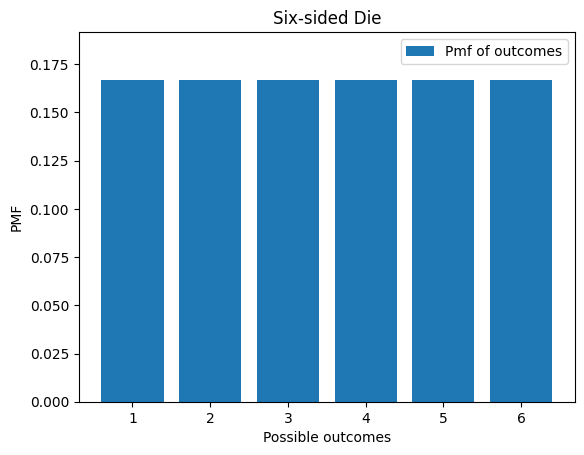

In [96]:
import matplotlib.pyplot as plt

die.bar(label='Pmf of outcomes')
plt.xlabel('Possible outcomes')
plt.ylabel('PMF')
plt.title('Six-sided Die')
plt.ylim(0, die.max() * 1.15)   # add ~30% headroom above the tallest bar so the legend has room
plt.legend()
plt.show()

In [97]:
def add_dist(pmf1, pmf2):
    res = Pmf()
    for q1, p1 in pmf1items():
        for q2, p2 in pmf2.items():
            q = q1 + q2
            p = p1 + p2
            res[q] = res(q) + p
    return res

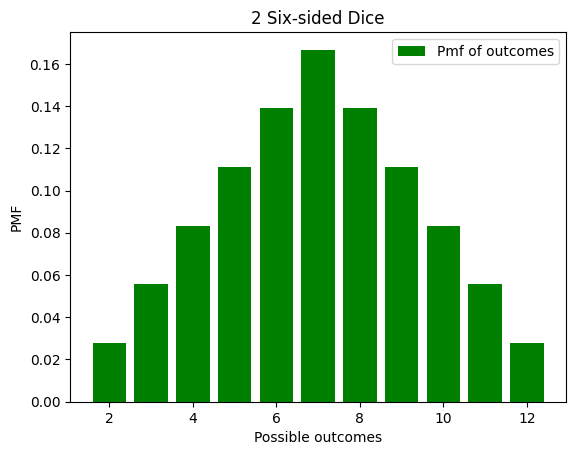

In [98]:
twice = die.add_dist(die)

#or 

twice = Pmf.add_dist(die, die)

twice.bar(label='Pmf of outcomes', color = 'green')
plt.xlabel('Possible outcomes')
plt.ylabel('PMF')
plt.title('2 Six-sided Dice')
plt.ylim(0, die.max() * 1.05)   
plt.legend()
plt.show()

In [99]:
def add_dist_seq(seq):
    total = seq[0]
    for other in seq[1:]:
        total= total.add_dist(other)
    return total

dice = [die] * 3
thrice = add_dist_seq(dice)

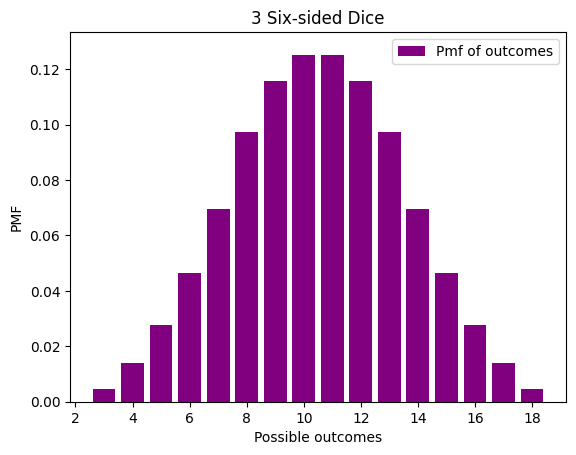

In [100]:
thrice.bar(label='Pmf of outcomes', color = 'purple')
plt.xlabel('Possible outcomes')
plt.ylabel('PMF')
plt.title('3 Six-sided Dice')
plt.ylim(0, die.max() * .8)   
plt.legend()
plt.show()

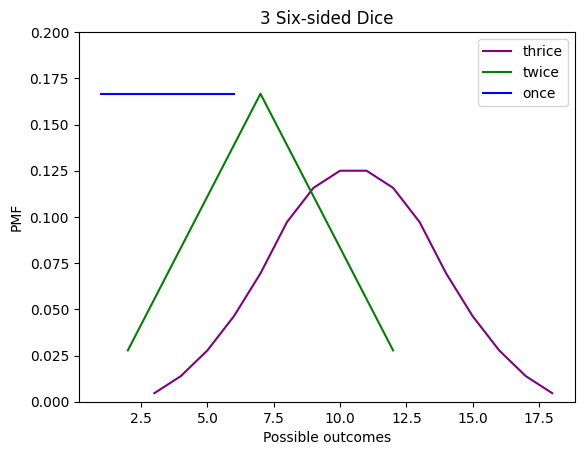

In [101]:
thrice.plot(label='thrice', color = 'purple')
twice.plot(label='twice', color = 'green')
die.plot(label='once', color = 'blue')
plt.xlabel('Possible outcomes')
plt.ylabel('PMF')
plt.title('3 Six-sided Dice')
plt.ylim(0, die.max() * 1.2)   
plt.legend()
plt.show()

## Gluten Sensitivity

Consider a paper that tests whether people diagnosed with gluten sensitivity (not celiac) are able to distinguish between flour and non-gluten flour. 

- Out of 35, 12 subjects correctly identified.
- 17 wrongly identified.
- 6 were unable to distinguish.

However, if none of the patients were sinsitive to gluten, some would identify it by chance. So, based on the data, can we model how many are sensitive and how many are guessing?

We'll make these assumptions:

- Sensitive people have a 95% chance of correctly identifying. 
- People who are not sensitive have a 40% chance. 

### The Forward Problem

Using our assumptions about the subjects, we'll comput distributions of the data. 

In [102]:
# The forward Problem

import os

from utils import make_binomial
num = 35
num_sensitive = 10
num_insensitive = num - num_sensitive

from utils import make_binomial

dist_sensitive = make_binomial(num_sensitive, 0.95)
dist_insensitive = make_binomial(num_insensitive, 0.40)

dist_total = Pmf.add_dist(dist_sensitive, dist_insenstive)

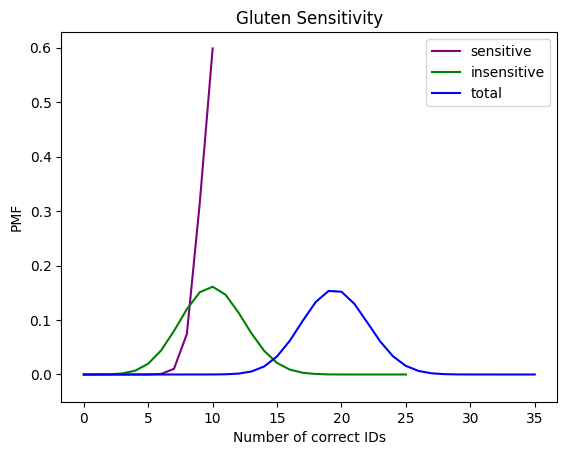

In [103]:
dist_sensitive.plot(label='sensitive', color = 'purple')
dist_insensitive.plot(label='insensitive', color = 'green')
dist_total.plot(label='total', color = 'blue')
plt.xlabel('Number of correct IDs')
plt.ylabel('PMF')
plt.title('Gluten Sensitivity')
plt.ylim(dist_sensitive.min() - .05, dist_sensitive.max() * 1.05)   
plt.legend()
plt.show()

### The Inverse Problem

Given the data, let's compute a posterior distribution of the number of sensitive subjects. 

In [109]:
import pandas as pd

table = pd.DataFrame()
for num_sensitive in range(0, num + 1):
    num_insensitive = num - num_sensitive
    dist_sensitive = make_binomial(num_sensitive, 0.95)
    dist_insenstive = make_binomial(num_insensitive, 0.4)
    dist_total = Pmf.add_dist(dist_sensitive, dist_insensitive)
    table[num_sensitive] = dist_total

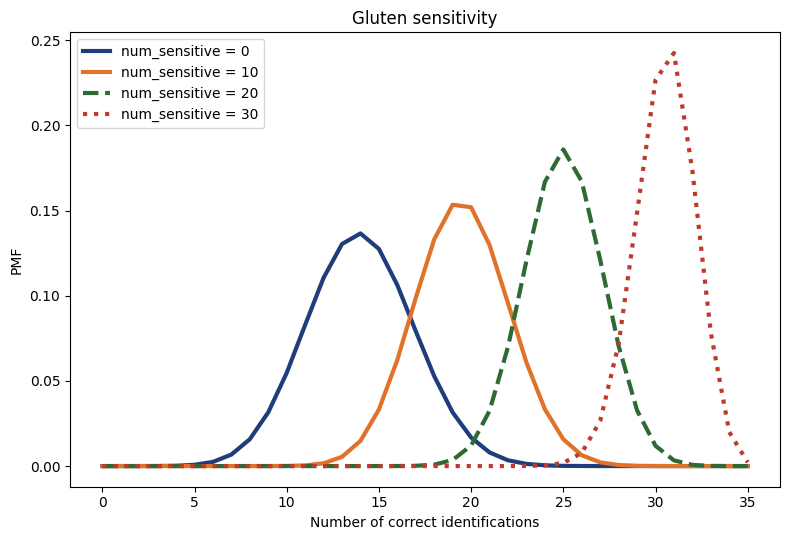

In [120]:
# the book's four selected columns and matching line styles
cols = [0, 10, 20, 30]
styles = ['-', '-', '--', ':']
colors = ['#1f3d7a', '#e0722a', '#2e6b34', '#c0392b']  # navy, orange, green, red

fig, ax = plt.subplots(figsize=(8, 5.5))
for col, style, color in zip(cols, styles, colors):
    ax.plot(table.index, table[col], linestyle=style, color=color,
            linewidth=3, label=f'num_sensitive = {col}')

ax.set_xlabel('Number of correct identifications')
ax.set_ylabel('PMF')
ax.set_title('Gluten sensitivity')
ax.legend()
plt.tight_layout()
plt.show()